## Example step-by-step operation of the Drift-PCA methodology

### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD, PCA

### Configuration

In [2]:
# Set seed for reproducible geometry
np.random.seed(42)
N = 150

c1_colors = ['#a6cee3', '#1f78b4'] # Blue
c2_colors = ['#fb9a99', '#e31a1c'] # Red

### Artificial Data Generation

In [3]:
X_pre_c1_raw = np.random.normal(loc=[3.0, 2.0], scale=0.5, size=(N, 2))
X_pre_c2_raw = np.random.normal(loc=[2.0, 1.0], scale=0.5, size=(N, 2))

X_post_c1_raw = np.random.normal(loc=[8.0, 1.0], scale=(0.75, 4.0), size=(N, 2))
X_post_c2_raw = np.random.normal(loc=[5.0, 4.0], scale=(2.0, 2.5), size=(N, 2))

### Standardize Data

In [4]:
X_pre_all = np.vstack([X_pre_c1_raw, X_pre_c2_raw])

mu_baseline = np.mean(X_pre_all, axis=0)
sigma_baseline = np.std(X_pre_all, axis=0)

X_pre_c1_std = (X_pre_c1_raw - mu_baseline) / sigma_baseline
X_pre_c2_std = (X_pre_c2_raw - mu_baseline) / sigma_baseline
X_post_c1_std = (X_post_c1_raw - mu_baseline) / sigma_baseline
X_post_c2_std = (X_post_c2_raw - mu_baseline) / sigma_baseline

### Calculate Drift Representation Vectors of Mean/Std Differences

In [5]:
# Class 1 Differences
delta_mu_c1 = np.mean(X_post_c1_std, axis=0) - np.mean(X_pre_c1_std, axis=0)
delta_sigma_c1 = np.std(X_post_c1_std, axis=0) - np.std(X_pre_c1_std, axis=0)

# Class 2 Differences
delta_mu_c2 = np.mean(X_post_c2_std, axis=0) - np.mean(X_pre_c2_std, axis=0)
delta_sigma_c2 = np.std(X_post_c2_std, axis=0) - np.std(X_pre_c2_std, axis=0)

D = np.vstack([delta_mu_c1, delta_sigma_c1, delta_mu_c2, delta_sigma_c2])
# D = np.vstack([delta_mu_c1, delta_mu_c2])

### Fit TruncatedSVD on the Drift Representation Matrix

In [6]:
svd = TruncatedSVD(n_components=2)
svd.fit(D)
V = svd.components_  # Orthogonal projection matrix

### Project the Original Data

In [7]:
X_pre_c1_proj = np.dot(X_pre_c1_std, V.T)
X_pre_c2_proj = np.dot(X_pre_c2_std, V.T)
X_post_c1_proj = np.dot(X_post_c1_std, V.T)
X_post_c2_proj = np.dot(X_post_c2_std, V.T)

## Visualizations

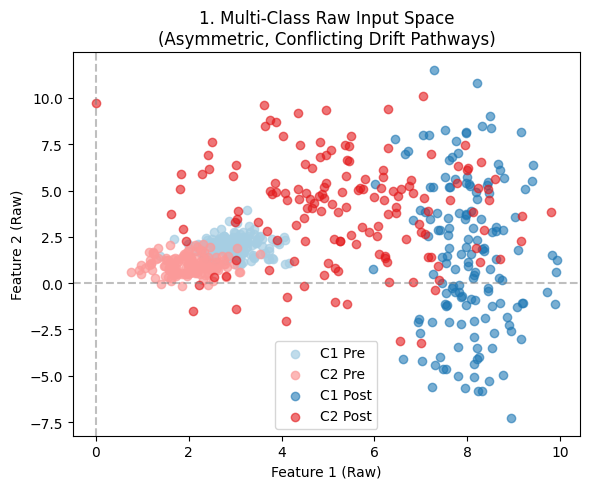

In [8]:
plt.figure(figsize=(6, 5))
plt.scatter(X_pre_c1_raw[:, 0], X_pre_c1_raw[:, 1], color=c1_colors[0], alpha=0.7, label='C1 Pre')
plt.scatter(X_pre_c2_raw[:, 0], X_pre_c2_raw[:, 1], color=c2_colors[0], alpha=0.7, label='C2 Pre')
plt.scatter(X_post_c1_raw[:, 0], X_post_c1_raw[:, 1], color=c1_colors[1], alpha=0.6, label='C1 Post')
plt.scatter(X_post_c2_raw[:, 0], X_post_c2_raw[:, 1], color=c2_colors[1], alpha=0.6, label='C2 Post')
plt.title("1. Multi-Class Raw Input Space\n(Asymmetric, Conflicting Drift Pathways)")
plt.xlabel("Feature 1 (Raw)")
plt.ylabel("Feature 2 (Raw)")
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

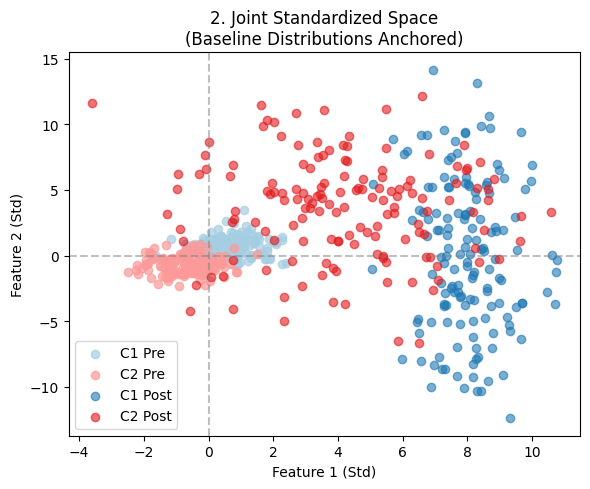

In [18]:
plt.figure(figsize=(6, 5))
plt.scatter(X_pre_c1_std[:, 0], X_pre_c1_std[:, 1], color=c1_colors[0], alpha=0.7, label="C1 Pre")
plt.scatter(X_pre_c2_std[:, 0], X_pre_c2_std[:, 1], color=c2_colors[0], alpha=0.7, label="C2 Pre")

plt.scatter(X_post_c1_std[:, 0], X_post_c1_std[:, 1], color=c1_colors[1], alpha=0.6, label="C1 Post")
plt.scatter(X_post_c2_std[:, 0], X_post_c2_std[:, 1], color=c2_colors[1], alpha=0.6, label="C2 Post")
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.title("2. Joint Standardized Space\n(Baseline Distributions Anchored)")
plt.xlabel("Feature 1 (Std)")
plt.ylabel("Feature 2 (Std)")
plt.legend()
plt.tight_layout()
plt.show()

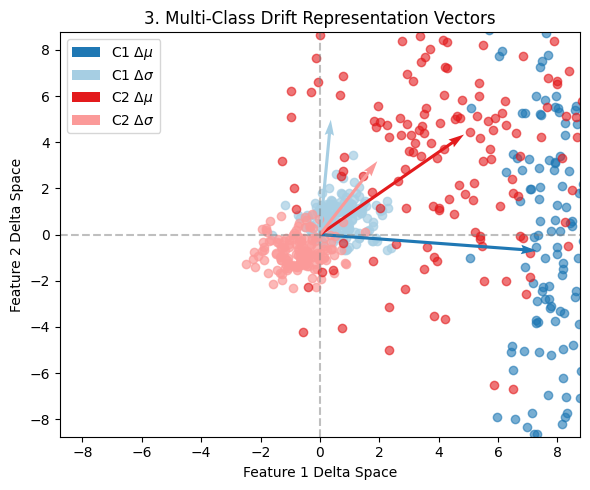

In [19]:
plt.figure(figsize=(6, 5))
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)

plt.scatter(X_pre_c1_std[:, 0], X_pre_c1_std[:, 1], color=c1_colors[0], alpha=0.7)
plt.scatter(X_pre_c2_std[:, 0], X_pre_c2_std[:, 1], color=c2_colors[0], alpha=0.7)
plt.scatter(X_post_c1_std[:, 0], X_post_c1_std[:, 1], color=c1_colors[1], alpha=0.6)
plt.scatter(X_post_c2_std[:, 0], X_post_c2_std[:, 1], color=c2_colors[1], alpha=0.6)

# Class 1 Vectors
plt.quiver(0, 0, delta_mu_c1[0], delta_mu_c1[1], angles='xy', scale_units='xy', scale=1, color=c1_colors[1], width=0.006, label=r'C1 $\Delta\mu$')
plt.quiver(0, 0, delta_sigma_c1[0], delta_sigma_c1[1], angles='xy', scale_units='xy', scale=1, color=c1_colors[0], width=0.006, label=r'C1 $\Delta\sigma$')
# Class 2 Vectors
plt.quiver(0, 0, delta_mu_c2[0], delta_mu_c2[1], angles='xy', scale_units='xy', scale=1, color=c2_colors[1], width=0.006, label=r'C2 $\Delta\mu$')
plt.quiver(0, 0, delta_sigma_c2[0], delta_sigma_c2[1], angles='xy', scale_units='xy', scale=1, color=c2_colors[0], width=0.006, label=r'C2 $\Delta\sigma$')
max_val = max(np.max(np.abs(D)), 1.0) * 1.2
plt.xlim(-max_val, max_val)
plt.ylim(-max_val, max_val)
plt.title("3. Multi-Class Drift Representation Vectors")
plt.xlabel("Feature 1 Delta Space")
plt.ylabel("Feature 2 Delta Space")
plt.legend()
plt.tight_layout()
plt.show()

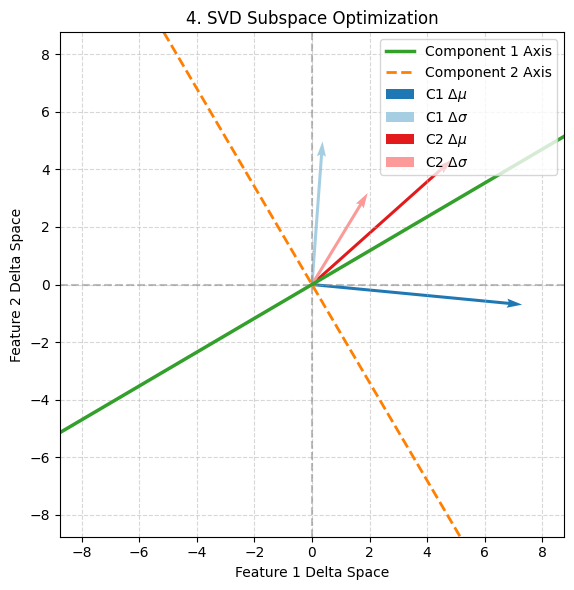

In [16]:
# 1. Changed to a 1:1 symmetric figure size
plt.figure(figsize=(6, 6))

plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)

# Subspace axes lines
plt.axline((0, 0), (V[0, 0], V[0, 1]), color='#33a02c', linewidth=2.5, label='Component 1 Axis')
plt.axline((0, 0), (V[1, 0], V[1, 1]), color='#ff7f00', linewidth=2.0, linestyle='--', label='Component 2 Axis')

# Class diff vectors
plt.quiver(0, 0, delta_mu_c1[0], delta_mu_c1[1], angles='xy', scale_units='xy', scale=1, color=c1_colors[1], width=0.006, label=r'C1 $\Delta\mu$')
plt.quiver(0, 0, delta_sigma_c1[0], delta_sigma_c1[1], angles='xy', scale_units='xy', scale=1, color=c1_colors[0], width=0.006, label=r'C1 $\Delta\sigma$')
plt.quiver(0, 0, delta_mu_c2[0], delta_mu_c2[1], angles='xy', scale_units='xy', scale=1, color=c2_colors[1], width=0.006, label=r'C2 $\Delta\mu$')
plt.quiver(0, 0, delta_sigma_c2[0], delta_sigma_c2[1], angles='xy', scale_units='xy', scale=1, color=c2_colors[0], width=0.006, label=r'C2 $\Delta\sigma$')

# plt.quiver(0, 0, D[0,0], D[0,1], angles='xy', scale_units='xy', scale=1, color=c1_colors[1], width=0.006)
# plt.quiver(0, 0, D[1,0], D[1,1], angles='xy', scale_units='xy', scale=1, color=c2_colors[1], width=0.006)

plt.xlim(-max_val, max_val)
plt.ylim(-max_val, max_val)

# 2. CRITICAL: Grab the current axes and enforce a square aspect ratio
plt.gca().set_aspect('equal', adjustable='box')

plt.title("4. SVD Subspace Optimization")
plt.xlabel("Feature 1 Delta Space")
plt.ylabel("Feature 2 Delta Space")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
D_proj = np.dot(D, V.T)
D_proj

array([[ 5.94030631, -4.30041857],
       [ 2.83582536,  4.10199522],
       [ 6.37882239,  1.27645968],
       [ 3.27774523,  1.76064688]])

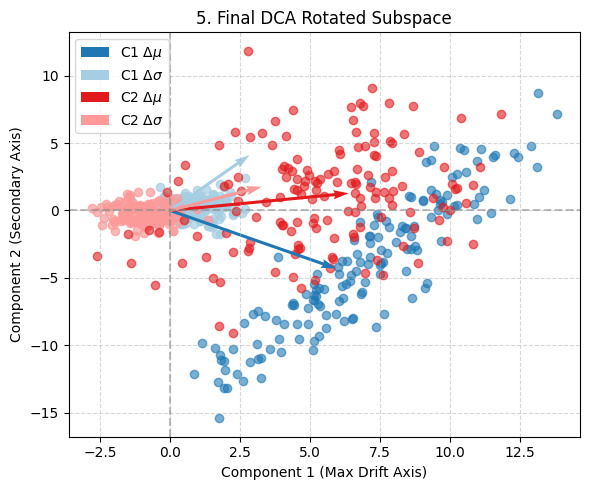

In [17]:
plt.figure(figsize=(6, 5))

plt.scatter(X_pre_c1_proj[:, 0], X_pre_c1_proj[:, 1], color=c1_colors[0], alpha=0.5+0.2)
plt.scatter(X_pre_c2_proj[:, 0], X_pre_c2_proj[:, 1], color=c2_colors[0], alpha=0.5+0.2)
plt.scatter(X_post_c1_proj[:, 0], X_post_c1_proj[:, 1], color=c1_colors[1], alpha=0.4+0.2)
plt.scatter(X_post_c2_proj[:, 0], X_post_c2_proj[:, 1], color=c2_colors[1], alpha=0.4+0.2)

plt.quiver(0, 0, D_proj[0, 0], D_proj[0, 1], angles='xy', scale_units='xy', scale=1, color=c1_colors[1], width=0.006, label=r'C1 $\Delta\mu$')
plt.quiver(0, 0, D_proj[1, 0], D_proj[1, 1], angles='xy', scale_units='xy', scale=1, color=c1_colors[0], width=0.006, label=r'C1 $\Delta\sigma$')

plt.quiver(0, 0, D_proj[0+2, 0], D_proj[0+2, 1], angles='xy', scale_units='xy', scale=1, color=c2_colors[1], width=0.006, label=r'C2 $\Delta\mu$')
plt.quiver(0, 0, D_proj[1+2, 0], D_proj[1+2, 1], angles='xy', scale_units='xy', scale=1, color=c2_colors[0], width=0.006, label=r'C2 $\Delta\sigma$')

plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)

plt.legend()

plt.title("5. Final DCA Rotated Subspace")
plt.xlabel("Component 1 (Max Drift Axis)")
plt.ylabel("Component 2 (Secondary Axis)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Comparison to PCA on Drift Representation Matrix

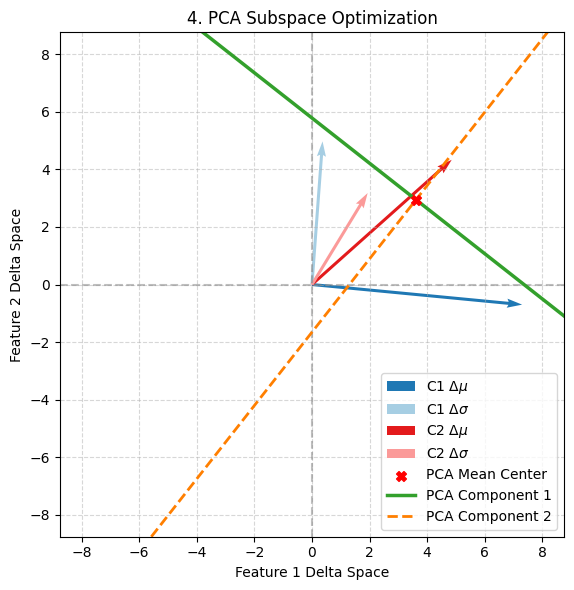

In [14]:
pca = PCA(n_components=2)
pca.fit(D)
V_pca = pca.components_
pca_center = pca.mean_  # The mean center of mass of the vector tips

# Setup a clean symmetrical boundary
max_val = max(np.max(np.abs(D)), 1.0) * 1.2

fig, ax = plt.subplots(figsize=(6, 6)) # Symmetric figure dimensions

ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)

# Plot the drift vectors starting from the true origin (0,0)
ax.quiver(0, 0, delta_mu_c1[0], delta_mu_c1[1], angles='xy', scale_units='xy', scale=1, color=c1_colors[1], width=0.006, label=r'C1 $\Delta\mu$')
ax.quiver(0, 0, delta_sigma_c1[0], delta_sigma_c1[1], angles='xy', scale_units='xy', scale=1, color=c1_colors[0], width=0.006, label=r'C1 $\Delta\sigma$')
ax.quiver(0, 0, delta_mu_c2[0], delta_mu_c2[1], angles='xy', scale_units='xy', scale=1, color=c2_colors[1], width=0.006, label=r'C2 $\Delta\mu$')
ax.quiver(0, 0, delta_sigma_c2[0], delta_sigma_c2[1], angles='xy', scale_units='xy', scale=1, color=c2_colors[0], width=0.006, label=r'C2 $\Delta\sigma$')

# plt.quiver(0, 0, D[0,0], D[0,1], angles='xy', scale_units='xy', scale=1, color=c1_colors[1], width=0.006)
# plt.quiver(0, 0, D[1,0], D[1,1], angles='xy', scale_units='xy', scale=1, color=c2_colors[1], width=0.006)

# Plot the vector tips 
ax.scatter(pca_center[0], pca_center[1], color='red', marker='X', s=50, zorder=4, label='PCA Mean Center')

# Draw PCA axes passing through the PCA mean center instead of (0,0)
ax.axline((pca_center[0], pca_center[1]), (pca_center[0] + V_pca[0, 0], pca_center[1] + V_pca[0, 1]), color='#33a02c', linewidth=2.5, label='PCA Component 1')
ax.axline((pca_center[0], pca_center[1]), (pca_center[0] + V_pca[1, 0], pca_center[1] + V_pca[1, 1]), color='#ff7f00', linewidth=2.0, linestyle='--', label='PCA Component 2')

ax.set_xlim(-max_val, max_val)
ax.set_ylim(-max_val, max_val)

ax.set_aspect('equal', adjustable='box')

ax.set_title("4. PCA Subspace Optimization")
ax.set_xlabel("Feature 1 Delta Space")
ax.set_ylabel("Feature 2 Delta Space")
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()

plt.tight_layout()
plt.show()